# Deforestation and Its Hidden Drivers
---

## Problem Statement

Every year, millions of hectares of forest disappear from the planet, and most of the time, we don't even notice. 
Deforestation is one of those slow-moving crises that rarely makes headlines the way a hurricane or an earthquake does, yet its consequences are massive: 
- loss of biodiversity
- acceleration of climate change
- soil degradation
- the displacement of communities that depend on forests for their survival

What makes it particularly hard to address is that we don't have a clear, agreed-upon picture of what actually drives it. Is it population growth? Poverty? Urbanization? Economic development? The intuitive answers are not always right. 
Some countries are highly urbanized and still preserve their forests. Others have strong economies and still cut them down.  There are patterns hidden in the data that we wouldn't guess just from common sense.

---

## Objective

This project uses regression analysis to dig into those patterns. Specifically, we aim to:

- **Understand which country-level characteristics are actually associated with deforestation** including some that are non-obvious (healthcare access, gasoline prices, geographic location).
- **Build a model that can estimate annual deforestation** for a country given its socio-economic profile, even for countries or scenarios we haven't seen before.
- **Compare a linear and a non-linear model** to see which better captures the complexity of the phenomenon.
- **Get inferences** identify which variables have statistically significant associations and what direction those associations go.

---

## Data Sources

Two independent public datasets are merged for this analysis:

| Dataset | Source | Description |
|---------|--------|-------------|
| World Data 2023 | World Bank indicators (compiled and hosted on Kaggle) | ~195 countries, 35 socio-economic indicators (population, GDP, health, education, etc.) |
| Annual Deforestation | Our World in Data | Annual forest loss in hectares by country and year |

After merging on country name and filtering to the most recent available year, we work with 106 countries* and a rich set of predictors. 

The target variable is **annual deforestation in hectares** — the number of hectares of forest lost in a given year. Because deforestation is a **continuous quantitative variable**, regression is the natural modeling choice: we are not asking *whether* a country deforests (classification) but *how much* and *why* (regression). This lets us quantify the strength of each relationship and generate predictions in interpretable units.

---



While the analysis is global, it is directly relevant to the **Mexican context**. Mexico holds some of the most biodiverse forests in the world — Oaxaca, Chiapas, and the Yucatán Peninsula — yet consistently ranks among countries with significant annual forest loss. Ideally, this analysis would be conducted at the Mexican state level, but that granularity of socio-economic and deforestation data is not yet publicly available in a consolidated form. Global country-level data serves as the necessary foundation: it allows us to identify which variables matter, build validated models, and establish a methodology that can be directly applied to Mexican state-level data as it becomes available. The global patterns found here are not abstract — they are the same structural forces at play in Mexico.

## Approach

The analysis follows a structured pipeline:
1. **Exploratory Data Analysis (EDA)** — understand distributions, spot outliers, check skewness
2. **Data Preparation** — handle skewed variables, drop leakage features, address collinearity
3. **Feature Selection** — use LASSO regularization to identify a meaningful subset of predictors
4. **Model Building** — fit a linear model (LASSO) and a non-linear model (Random Forest)
    - Justification: both LASSO and Random Forest help compare a high-interpretability linear baseline against a flexible non-linear approach capable of capturing complex socio-economic interactions. This dual-modeling strategy allows us to validate if deforestation drivers follow a simple proportional trend or not. Additionally not only do they give the area for the same metrics, but they give off both predictive and inferential power, sometimes rf more than Lasso, which helps understand the importance of interpretable against less interpretable models. Both are also regression models that dont classify but allow can predict continuous values. 
5. **Evaluation** — compare models using R², RMSE, and MAE on a held-out validation set
6. **Inference** — use OLS to extract statistically significant associations and confidence intervals


We start by loading both raw datasets into memory. The **World Data 2023** file provides the socio-economic predictors for each country, while the **Annual Deforestation** file provides our target variable: hectares of forest lost per year. Since these come from two independent sources with different country naming conventions, they will need to be merged carefully before any analysis can begin.

In [1]:
import pandas as pd 

# load the datasets 
country_path = "data/world-data/world-data-2023.csv"
deforestation_path = "data/deforestation/annual-deforestation.csv"

country_data = pd.read_csv(country_path)
deforestation_data = pd.read_csv(deforestation_path)

# have to analyze how the countries are prsented to see if we can merge 
print("First 5 rows of country dataset")
country_data.head()

First 5 rows of country dataset


,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [2]:
print("First 5 rows of deforestation data set")
deforestation_data.head()

First 5 rows of deforestation data set


,Entity,Code,Year,Deforestation
0,Algeria,DZA,2020,8670
1,Angola,AGO,2020,510440
2,Argentina,ARG,2020,195300
3,Austria,AUT,2020,5130
4,Bahrain,BHR,2020,0


## Data Dictionaries

---

### Dataset 1 — World Data 2023 (Kaggle)
One row per country (~195 countries). Contains socio-economic, demographic, and geographic indicators.

| Variable | Type | Description |
|----------|------|-------------|
| Country | Text | Country name (used as merge key) |
| Density (P/Km²) | Numeric | Population density in people per km² |
| Agricultural Land (%) | Numeric | Share of land used for agriculture |
| Land Area (Km²) | Numeric | Total land area — *dropped* |
| Armed Forces size | Numeric | Number of active military personnel |
| Birth Rate | Numeric | Births per 1,000 people per year |
| Co2-Emissions | Numeric | Total CO₂ emissions (kt) |
| CPI | Numeric | Consumer Price Index — measures price level |
| CPI Change (%) | Numeric | Annual inflation rate |
| Fertility Rate | Numeric | Average children per woman |
| Forested Area (%) | Numeric | Current share of land that is forested — *dropped* |
| Gasoline Price | Numeric | Average retail gasoline price (USD/liter) |
| GDP | Numeric | Gross Domestic Product (USD) |
| Gross primary education enrollment (%) | Numeric | % of primary-school-age children enrolled |
| Gross tertiary education enrollment (%) | Numeric | % of tertiary-age population enrolled in university |
| Infant mortality | Numeric | Deaths per 1,000 live births before age 1 |
| Life expectancy | Numeric | Average years a newborn is expected to live |
| Maternal mortality ratio | Numeric | Deaths per 100,000 live births due to pregnancy/childbirth |
| Minimum wage | Numeric | National minimum wage (USD/month) |
| Out of pocket health expenditure | Numeric | Share of health costs paid directly by citizens (%) |
| Physicians per thousand | Numeric | Number of doctors per 1,000 people |
| Population | Numeric | Total population |
| Population: Labor force participation (%) | Numeric | Share of working-age population employed or seeking work |
| Tax revenue (%) | Numeric | Government tax revenue as % of GDP |
| Total tax rate | Numeric | Total tax burden on businesses (% of commercial profits) |
| Unemployment rate | Numeric | % of labor force without a job |
| Urban_population | Numeric | Number of people living in urban areas |
| Latitude | Numeric | Geographic latitude of country centroid |
| Longitude | Numeric | Geographic longitude of country centroid |
| *Administrative columns* | Text | Abbreviation, Currency-Code, Calling Code, Capital/Major City, Largest city, Official language — *all dropped* |

---

### Dataset 2 — Annual Deforestation (Our World in Data)
One row per country per year. Tracks annual forest loss globally.

| Variable | Type | Description |
|----------|------|-------------|
| Entity | Text | Country name (used as merge key) |
| Code | Text | ISO country code — *dropped* |
| Year | Numeric | Year of observation — *dropped* |
| Deforestation | Numeric | **Target variable** — hectares of forest lost that year |


Before merging, we need to verify how many countries each dataset contains and how well the country names align. A mismatch in naming conventions (e.g. 'United States' vs 'United States of America') would silently drop valid countries during the join. Checking the overlap explicitly lets us know exactly how many countries will make it into the final merged dataset and flag any naming issues worth investigating.

In [3]:
# lets compare the shape of both datasets
# (rows, columns)
print(f"Country info, country rows: {country_data.shape[0]}")
print(f"Deforestation info, country rows: {deforestation_data.shape[0]}")


Country info, country rows: 195
Deforestation info, country rows: 113


In [4]:
# find what the not matches are, and delete... we dont have the data
indices = country_data['Country'].isin(deforestation_data['Entity'])
inverse = [True if i==False else False for i in indices]
print(country_data[inverse])

                  Country Density\n(P/Km2) Abbreviation Agricultural Land( %)  \
0             Afghanistan               60           AF                58.10%   
1                 Albania              105           AL                43.10%   
3                 Andorra              164           AD                40.00%   
5     Antigua and Barbuda              223           AG                20.50%   
7                 Armenia              104           AM                58.90%   
..                    ...              ...          ...                   ...   
183               Ukraine               75           UA                71.70%   
184  United Arab Emirates              118           AE                 5.50%   
186         United States               36           US                44.40%   
189               Vanuatu               25           VU                15.30%   
193                Zambia               25           ZM                32.10%   

    Land Area(Km2) Armed Fo

In [5]:
countries_in_deforestation = set(deforestation_data['Entity'].unique())
countries_in_stats = set(country_data['Country'].unique())
overlap = countries_in_deforestation & countries_in_stats
print(f"Countries in common: {overlap}")

Countries in common: {'Burkina Faso', 'Lithuania', 'Nauru', 'Uzbekistan', 'Malta', 'Guatemala', 'Monaco', 'Romania', 'Costa Rica', 'United Kingdom', 'Angola', 'Yemen', 'Portugal', 'Slovenia', 'Jordan', 'Italy', 'Ethiopia', 'Libya', 'India', 'Senegal', 'Uganda', 'Honduras', 'Saint Vincent and the Grenadines', 'Cameroon', 'Austria', 'Morocco', 'Bulgaria', 'Paraguay', 'San Marino', 'Estonia', 'Tunisia', 'Togo', 'Canada', 'Tanzania', 'Eswatini', 'Colombia', 'Guinea', 'Saudi Arabia', 'Papua New Guinea', 'Venezuela', 'Serbia', 'Malawi', 'Oman', 'Madagascar', 'Switzerland', 'Latvia', 'Djibouti', 'Kazakhstan', 'El Salvador', 'Russia', 'Denmark', 'Zimbabwe', 'Chile', 'Iraq', 'Suriname', 'Hungary', 'Bhutan', 'Sudan', 'Finland', 'Croatia', 'Argentina', 'Syria', 'Gabon', 'Equatorial Guinea', 'Georgia', 'Spain', 'Namibia', 'Vietnam', 'Cuba', 'Lebanon', 'Panama', 'Iran', 'Dominican Republic', 'Poland', 'Brazil', 'Guyana', 'Iceland', 'Uruguay', 'Jamaica', 'Somalia', 'Singapore', 'Kuwait', 'Norway', '

With confirmed overlap of country names between both datasets, we can now merge them. An **inner join** on country name keeps only the countries that appear in *both* datasets; meaning we only keep countries for which we have both socio-economic indicators *and* a deforestation record. Countries that exist in one dataset but not the other are dropped. This is the right trade-off: a smaller but complete dataset is far better than a large one full of gaps in the target variable.

In [6]:
merged_df = country_data.merge(deforestation_data, 
                         left_on='Country', 
                         right_on='Entity', 
                         how='inner')
merged_df.shape
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 39 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    106 non-null    object 
 1   Density
(P/Km2)                            106 non-null    object 
 2   Abbreviation                               104 non-null    object 
 3   Agricultural Land( %)                      103 non-null    object 
 4   Land Area(Km2)                             106 non-null    object 
 5   Armed Forces size                          98 non-null     object 
 6   Birth Rate                                 104 non-null    float64
 7   Calling Code                               106 non-null    float64
 8   Capital/Major City                         104 non-null    object 
 9   Co2-Emissions                              102 non-null    object 
 10  CPI                       

In [7]:
# how many nulls? do we need ot fill it up
merged_df.isnull().sum()

Country                                       0
Density\n(P/Km2)                              0
Abbreviation                                  2
Agricultural Land( %)                         3
Land Area(Km2)                                0
Armed Forces size                             8
Birth Rate                                    2
Calling Code                                  0
Capital/Major City                            2
Co2-Emissions                                 4
CPI                                           7
CPI Change (%)                                7
Currency-Code                                 8
Fertility Rate                                3
Forested Area (%)                             3
Gasoline Price                                7
GDP                                           0
Gross primary education enrollment (%)        3
Gross tertiary education enrollment (%)       3
Infant mortality                              3
Largest city                            

The null check reveals missing values scattered across several columns. This is expected with real-world country data — not every country reports every indicator every year. Before deciding how to handle them, we first need to drop the administrative columns that add no analytical value (language, currency, calling code, etc.), then reassess the null landscape on the cleaned dataset. That way we're not wasting effort imputing columns we were going to drop anyway.

In [8]:
unnecesessary_cols = [
    'Abbreviation', 
    'Official language', 
    'Currency-Code', 
    'Entity', 
    'Code', 
    'Capital/Major City', 
    'Calling Code',
    'Largest city',
    'Year',
    'Country'
]
simplified_df = merged_df.drop(columns=unnecesessary_cols)

In [9]:
# how many nulls? do we need ot fill it up
simplified_df.isnull().sum()

Density\n(P/Km2)                              0
Agricultural Land( %)                         3
Land Area(Km2)                                0
Armed Forces size                             8
Birth Rate                                    2
Co2-Emissions                                 4
CPI                                           7
CPI Change (%)                                7
Fertility Rate                                3
Forested Area (%)                             3
Gasoline Price                                7
GDP                                           0
Gross primary education enrollment (%)        3
Gross tertiary education enrollment (%)       3
Infant mortality                              3
Life expectancy                               3
Maternal mortality ratio                      6
Minimum wage                                 23
Out of pocket health expenditure              4
Physicians per thousand                       3
Population                              

Before diving into imputation, it is useful to check the full structure of the dataset — column names, non-null counts, and inferred data types — using `.info()`. This confirms which columns pandas read as numeric vs. object (text), which directly determines how we handle each column in the next steps.

In [10]:
simplified_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Density
(P/Km2)                            106 non-null    object 
 1   Agricultural Land( %)                      103 non-null    object 
 2   Land Area(Km2)                             106 non-null    object 
 3   Armed Forces size                          98 non-null     object 
 4   Birth Rate                                 104 non-null    float64
 5   Co2-Emissions                              102 non-null    object 
 6   CPI                                        99 non-null     object 
 7   CPI Change (%)                             99 non-null     object 
 8   Fertility Rate                             103 non-null    float64
 9   Forested Area (%)                          103 non-null    object 
 10  Gasoline Price            

## Categorical Values

In this stage, we need to examine the columns that Pandas classified as object type. This is a vital step because, in a clean dataset, "object" usually means text or categories (like names of countries). However, by using the .select_dtypes(include=['object']) function, we can isolate these specific columns to see if they truly belong there or if they require a transformation. By storing these names in the categorical_cols variable and printing them, we gain a clear roadmap of which variables aren't currently "mathematically active" in our dataframe. To get a better look at what is actually inside them, we visualize the .head() of these specific columns.

This revealed that many of these columns, such as GDP, Population, and Tax Revenue, are actually numerical. They were misclassified as objects because they contain extra characters like dollar signs ($), percent symbols (%), and commas used as thousands separators. This finding is a critical turning point in our EDA. It means we cannot currently calculate correlations, see distributions, or include these variables in a regression model. 

Code Summary for the next cell:

- Identification: Isolate columns where dtype == object.
- Validation: Use .head() to spot the symbols blocking the math.


In [11]:
categorical_cols = simplified_df.select_dtypes(include=['object']).columns
print(f"Categorical columns: {categorical_cols}")
simplified_df[categorical_cols].head()

Categorical columns: Index(['Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
       'Armed Forces size', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Forested Area (%)', 'Gasoline Price', 'GDP',
       'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Minimum wage',
       'Out of pocket health expenditure', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population'],
      dtype='object')


,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Co2-Emissions,CPI,CPI Change (%),Forested Area (%),Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Minimum wage,Out of pocket health expenditure,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,18,17.40%,"2,381,741","317,000","150,006",151.36,2.00%,0.80%,$0.28,"$169,988,236,398",109.90%,51.40%,$0.95,28.10%,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100"
1,26,47.50%,"1,246,700","117,000","34,693",261.73,17.10%,46.30%,$0.97,"$94,635,415,870",113.50%,9.30%,$0.71,33.40%,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025"
2,17,54.30%,"2,780,400","105,000","201,348",232.75,53.50%,9.80%,$1.10,"$449,663,446,954",109.70%,90.00%,$3.35,17.60%,"44,938,712",61.30%,10.10%,106.30%,9.79%,"41,339,571"
3,109,32.40%,"83,871","21,000","61,448",118.06,1.50%,46.90%,$1.20,"$446,314,739,528",103.10%,85.10%,NaN,17.90%,"8,877,067",60.70%,25.40%,51.40%,4.67%,"5,194,416"
4,"2,239",11.10%,765,"19,000","31,694",117.59,2.10%,0.80%,$0.43,"$38,574,069,149",99.40%,50.50%,NaN,25.10%,"1,501,635",73.40%,4.20%,13.80%,0.71%,"1,467,109"


Based on this analysis, we can confidently decide to transform all categorical columns into numerical values — they all hold important information that we need for modeling and inference. The steps taken are:
1. Use `astype(str)` to ensure all categorical columns are treated as strings — mainly a safety check before manipulation.
2. Loop over each categorical column and use `str.replace()` with a regex pattern to remove currency symbols (`$`, `%`, `,`), replacing them with an empty string. Then convert the cleaned column to numeric using `pd.to_numeric(errors='coerce')`, which safely turns any remaining non-numeric values into `NaN` instead of crashing.
3. Finally, run `describe()` again to confirm the transformation worked — `describe()` only summarizes numeric columns, so if the previously categorical columns now appear in the output, the conversion was successful.

In [12]:
import numpy as np

# treat everything as text 
simplified_df[categorical_cols] = simplified_df[categorical_cols].astype(str)

# replace the symbols 
for col in categorical_cols:
    simplified_df[col] = simplified_df[col].str.replace(r'[$%,]', '', regex=True)
    # convert to numeric, errors='coerce' will turn non-convertible values into NaN
    simplified_df[col] = pd.to_numeric(simplified_df[col], errors='coerce')

# check the data types again
simplified_df[categorical_cols].describe()



,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Co2-Emissions,CPI,CPI Change (%),Forested Area (%),Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Minimum wage,Out of pocket health expenditure,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
count,106.000000,103.000000,1.060000e+02,9.800000e+01,1.020000e+02,99.000000,99.000000,103.000000,99.000000,1.060000e+02,103.000000,103.000000,83.000000,102.000000,1.060000e+02,100.00000,94.000000,101.000000,100.000000,1.040000e+02
mean,479.150943,39.030097,8.851272e+05,1.727143e+05,2.292163e+05,183.278586,7.494949,29.903883,1.025354,5.149246e+11,101.866990,41.160194,2.101928,32.097059,5.103524e+07,62.05500,15.976596,42.265347,6.643900,2.881799e+07
std,2672.263495,21.525411,2.277325e+06,4.437516e+05,1.019249e+06,292.839470,26.992650,23.294428,0.376315,2.012593e+12,14.934658,28.509236,2.740145,17.371534,1.899496e+08,10.71333,7.174139,23.669113,4.540792,9.651982e+07
min,3.000000,0.600000,2.000000e+00,0.000000e+00,5.100000e+01,99.550000,-4.300000,0.000000,0.000000,1.330000e+08,23.400000,0.800000,0.010000,5.800000,1.008400e+04,38.00000,0.000000,9.900000,0.090000,5.464000e+03
25%,25.000000,22.250000,5.247350e+04,1.350000e+04,5.879000e+03,113.820000,0.950000,9.750000,0.785000,1.513707e+10,97.500000,12.700000,0.405000,18.000000,3.807162e+06,55.77500,11.250000,31.600000,3.457500,2.688883e+06
50%,76.000000,39.300000,2.266800e+05,3.150000e+04,2.495200e+04,123.780000,2.300000,31.100000,1.030000,5.398074e+10,101.900000,40.100000,1.160000,28.700000,1.027744e+07,62.25000,15.200000,37.700000,5.375000,5.894282e+06
75%,163.500000,54.850000,6.339888e+05,1.235000e+05,9.631325e+04,156.785000,3.700000,44.700000,1.275000,2.789289e+11,108.600000,67.100000,2.330000,41.550000,3.314181e+07,68.80000,20.875000,48.200000,8.747500,1.770477e+07
max,26337.000000,82.600000,1.709824e+07,3.031000e+06,9.893038e+06,2740.270000,254.900000,98.300000,2.000000,1.991000e+13,142.500000,94.300000,11.720000,81.000000,1.397715e+09,86.80000,37.200000,219.600000,20.270000,8.429340e+08


**Observations from `describe()`**

**1. Enrollment above 100%:** The Gross Primary Education Enrollment column shows values above 100%, which at first looks like a data error. It is not. The Gross Enrollment Ratio counts *all* students currently in primary school regardless of age, divided by the official primary-age population. In many developing countries students start late or repeat grades, so the actual number of enrolled students exceeds the official-age count. A value of 140% simply means the system is absorbing over-age students — the data is valid and we keep it as-is.

**2. Land area extremes:** The smallest land area in the dataset belongs to Vatican City (~0.44 km²) and the largest to Russia (>17,000,000 km²). Both values were verified against Britannica and are accurate. This extreme range confirms why Land Area was flagged as a poor predictor — it is a geographic constant that reflects size, not environmental pressure.

In [13]:
# before dropping the unncessesary cols, just check if the data is real with the lwoest and higest land values to see if they match the bigges
# Assuming country_data is already loaded as a DataFrame
# Convert the 'Land Area(Km2)' column to numeric, because it is no longer in the simplified... 
country_data['Land Area(Km2)'] = pd.to_numeric(country_data['Land Area(Km2)'].str.replace(',', ''), errors='coerce')

# Get the lowest and highest values along with the corresponding countries
lowest_land_area = country_data.loc[country_data['Land Area(Km2)'].idxmin()]
highest_land_area = country_data.loc[country_data['Land Area(Km2)'].idxmax()]

# Display the results
print("Country with the lowest land area:")
print(lowest_land_area[['Country', 'Land Area(Km2)']])

print("\nCountry with the highest land area:")
print(highest_land_area[['Country', 'Land Area(Km2)']])

Country with the lowest land area:
Country           Vatican City
Land Area(Km2)             0.0
Name: 73, dtype: object

Country with the highest land area:
Country               Russia
Land Area(Km2)    17098240.0
Name: 143, dtype: object


## Dealling with the nulls
After having all our categorical values in order, we now have to see how to deal with the null valuespresent and anlyze the % of nulls per column, to see if tits even worth keeping. We will calculate the % of nulls per column to see if its biger than 50% we will drop them as they will help less than they can if we have them. 
In this case we did that by dividing the count of null per col by the total number of rows in the data and multiplying * 100 .. SWe decided to add the round(x, 2) function to keep it cleaner. Her we could tell from these that are columns that have nulls can be managebale with the biggest one being a bit over 21%, now its time to explore what to fill it with based on the outliers and ure of the the data

In [14]:
# how many nulls? do we need ot fill it up... get the % of nulls
print(round(((simplified_df.isnull().sum())/simplified_df.shape[0]) * 100,2))

Density\n(P/Km2)                              0.00
Agricultural Land( %)                         2.83
Land Area(Km2)                                0.00
Armed Forces size                             7.55
Birth Rate                                    1.89
Co2-Emissions                                 3.77
CPI                                           6.60
CPI Change (%)                                6.60
Fertility Rate                                2.83
Forested Area (%)                             2.83
Gasoline Price                                6.60
GDP                                           0.00
Gross primary education enrollment (%)        2.83
Gross tertiary education enrollment (%)       2.83
Infant mortality                              2.83
Life expectancy                               2.83
Maternal mortality ratio                      5.66
Minimum wage                                 21.70
Out of pocket health expenditure              3.77
Physicians per thousand        

We will now plot with the help of matplotlib and seaborn some boxplots to visually see the outliers, the number of them, the shape of the data and decide how to move foward with them.

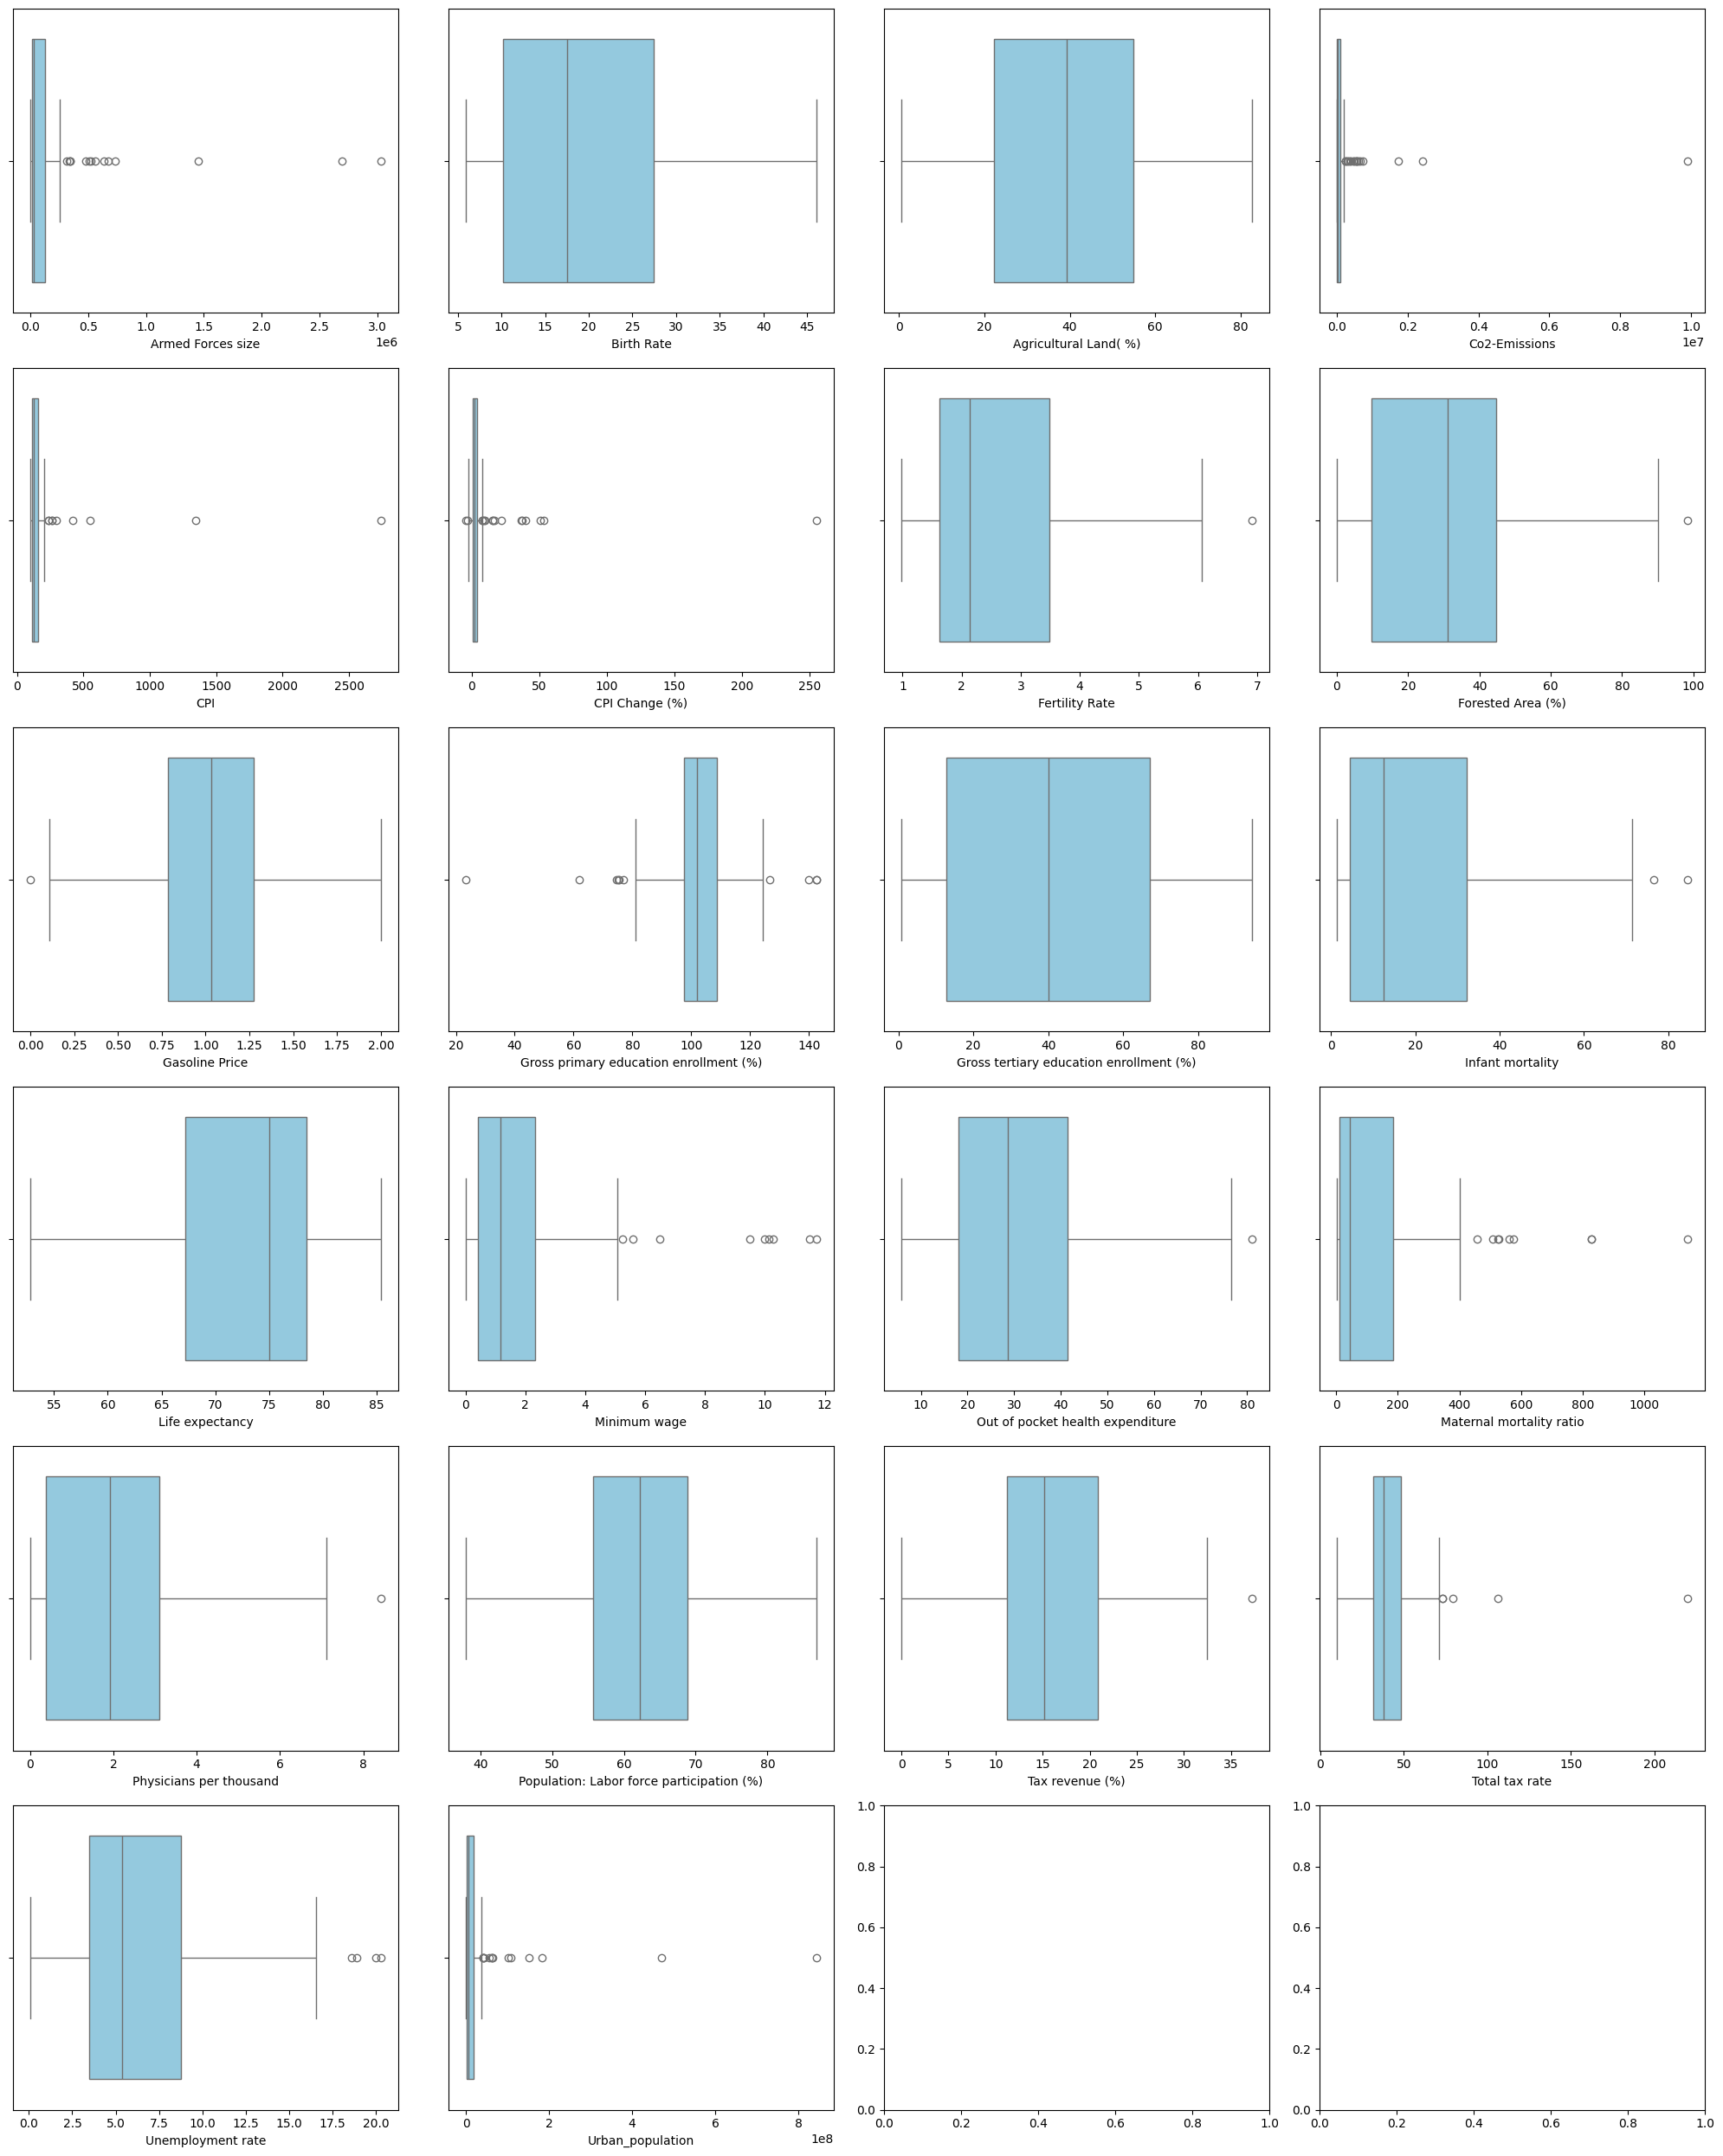

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = [
    'Armed Forces size', 'Birth Rate', 'Agricultural Land( %)', 
    'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Fertility Rate', 'Forested Area (%)', 
    'Gasoline Price', 'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)',
    'Infant mortality', 'Life expectancy', 'Minimum wage', 'Out of pocket health expenditure', 'Maternal mortality ratio',
    'Physicians per thousand', 'Population: Labor force participation (%)', 'Tax revenue (%)', 'Total tax rate', 
    'Unemployment rate', 'Urban_population'
]

# get the grid 
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col in simplified_df.columns:
        sns.boxplot(x=simplified_df[col], ax=axes[i], color='skyblue')
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()

After analyzing the distribution of our variables through box plots, we can define a tailored imputation strategy. Filling null values is not just about "filling the gaps," but about preserving the statistical integrity of the dataset to ensure our future predictions are not biased

### **Mean**

For variables with a relatively symmetric distribution and minimal outliers, the Mean is the most efficient representative value. In these cases, the data points are evenly distributed around the center, so the average accurately reflects the "typical" country in the set. We calculate the average of the existing data and replace NaN entries with this single value. For this, we use the .fillna() function from Pandas, feeding it the pre-calculated .mean() for the col we are working on in the loop of all the columns to impute the mean of.

* Variables: Birth rate, agricultural land (%), fertility rate, forested area, gasoline price, gross tertiary education, out-of-pocket health expenditure, physicians per thousand, labor force participation, and tax revenue.



In [16]:
# set the columns to inpute the mean
cols_mean_imputation = ['Birth Rate', 'Agricultural Land( %)', 'Fertility Rate', 'Forested Area (%)', 'Gasoline Price', 
                        'Gross tertiary education enrollment (%)', 'Population: Labor force participation (%)', 'Tax revenue (%)', 
                        'Out of pocket health expenditure', 'Physicians per thousand']
for col in cols_mean_imputation:
    if col in simplified_df.columns:
        mean_value = simplified_df[col].mean()
        simplified_df[col] = simplified_df[col].fillna(mean_value)
    else:
        print(f"Column '{col}' not found in the DataFrame.")

# check that it worked
simplified_df[cols_mean_imputation].isnull().sum()

Birth Rate                                   0
Agricultural Land( %)                        0
Fertility Rate                               0
Forested Area (%)                            0
Gasoline Price                               0
Gross tertiary education enrollment (%)      0
Population: Labor force participation (%)    0
Tax revenue (%)                              0
Out of pocket health expenditure             0
Physicians per thousand                      0
dtype: int64

### **Median**

When a dataset has "extreme" outliers (values that are much larger or smaller than the rest) the mean becomes "fake" because it is pulled toward those extremes. The Median (the middle value) is far more accurate; it doesn't care if the richest country has a GDP of 1 billion or 100 trillion; it only cares about the central position. The numerous dots outside the main range in our box plots indicate that a few countries would disproportionately inflate the average. The median ensures our "typical" value remains grounded. Here we use the .fillna() function from Pandas, feeding it the pre-calculated .median() of each specific column.

- Variables: Unemployment rate, urban population, gross primary education enrollment, total tax rate, CPI, armed forces size, and CO2 Emissions.

In [17]:
# get the cols to impute with the median
cols_median_imputation = ['Armed Forces size', 'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Co2-Emissions',
                          'Gross primary education enrollment (%)', 'Total tax rate',
                            'Unemployment rate', 'Urban_population']

for col in cols_median_imputation:
    if col in simplified_df.columns:
        median_value = simplified_df[col].median()
        simplified_df[col] = simplified_df[col].fillna(median_value)
    else:
        print(f"Column '{col}' not found in the DataFrame.")

# check that it worked
simplified_df[cols_median_imputation].isnull().sum()

Armed Forces size                         0
Co2-Emissions                             0
CPI                                       0
CPI Change (%)                            0
Co2-Emissions                             0
Gross primary education enrollment (%)    0
Total tax rate                            0
Unemployment rate                         0
Urban_population                          0
dtype: int64

### **KNN**

For complex socio-economic indicators, a simple average (mean or median) might be too "lazy." K-Nearest Neighbors (KNN) is a more sophisticated approach. Instead of looking at one variable in isolation, it looks at the "whole profile" of a country. hese variables are deeply interconnected. If a country is missing its "Life Expectancy" value, it makes more sense to look at the average of 5 countries with similar wealth and health infrastructure than to simply use the global average. Here the algorithm finds the "K" (we will use in this case 5 because according to refrences, like Borade (2025), a data of between 4-7 is the best for smaller datasets like ours) most similar records based on other available features and calculates a weighted average of their values to fill the missing cell.

- Variables: Minimum wage, infant mortality, maternal mortality ratio, and life expectancy.
- Standarization: to be able to use the KNN we need to normalize the data between a similar scale to allow for no variable to dominate the decision over te others. This will be used over normalization because normalization is very sensitive to outliers, and our datapoint have important datapoint outliers that we dont wanna "squash". This centers the data so the mean is 0 and the standard deviation is 1. 

So our workflow will follow the following logic: 
1. We take our specific columns and "standardize" them. This puts them all on a level playing field (Z-scores) so that a "high" CO2 emission and a "high" Infant Mortality are mathematically comparable. We will use StandardScaler from sklearn. 
2. Imputation (K=5): The KNNImputer looks at each country with a missing value and finds its 5 nearest neighbors based on their Z-scores. It then calculates the average of those 5 neighbors to fill the gap.

De-scaling (Inverse Transform): Because we can't report "Z-scores" in our final results, we must convert the data back to its original units (dollars, tons, or years).


In [18]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# first we scale the data 
cols_knn_inputation = ['Minimum wage', 
    'Infant mortality', 
    'Maternal mortality ratio', 
    'Life expectancy', 
]

print("Nulls before KNN Imputation:\n", simplified_df[cols_knn_inputation].isnull().sum())

# standarization (z-scores)
scaler = StandardScaler()
# learn the shape of data then uses those to tranform it 
scaled_knn_col_data = scaler.fit_transform(simplified_df[cols_knn_inputation])

# define the imputer
imputer = KNNImputer(n_neighbors=5)

# fill gaps with the z matrix
imputed_scaled_data = imputer.fit_transform(scaled_knn_col_data)

# return back to normal 
imputed_data_original_scale = scaler.inverse_transform(imputed_scaled_data)

# replace the cols with the one without nulls
simplified_df[cols_knn_inputation] = imputed_data_original_scale

# check that it worked
print("\nNulls after KNN Imputation:\n", simplified_df[cols_knn_inputation].isnull().sum())

Nulls before KNN Imputation:
 Minimum wage                23
Infant mortality             3
Maternal mortality ratio     6
Life expectancy              3
dtype: int64

Nulls after KNN Imputation:
 Minimum wage                0
Infant mortality            0
Maternal mortality ratio    0
Life expectancy             0
dtype: int64


We continued by using a descibre() function, this provides a comprehensive overview of the quantitative data, its from here that we can tell that there's a variety of countries included in this list as the ranges are pretty extensive, as its the case with the maternity rate witha standard deviation of 207.25. There are outliers, but outliers that seem to be within the ranges of potentially valid answers, as just like in C02 emissions or GDP in big countries, we can tell that deforestation can be increased in for instance (base don research and matching) Brasil where big fires and the amazonas are overgoing deep deforestation rates. However, based on this and what we want to eventually do its important we normalize the data for further handlling. 

In [19]:
# Statistical summary
simplified_df.describe()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,Forested Area (%),...,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude,Deforestation
count,106.000000,106.000000,1.060000e+02,1.060000e+02,106.000000,1.060000e+02,106.000000,106.000000,106.000000,106.000000,...,106.000000,1.060000e+02,106.000000,106.000000,106.00000,106.000000,1.060000e+02,106.000000,106.000000,1.060000e+02
mean,479.150943,39.030097,8.851272e+05,1.620566e+05,19.531538,2.215082e+05,179.349434,7.151887,2.634369,29.903883,...,2.067961,5.103524e+07,62.055000,15.976596,42.05000,6.572075,2.838547e+07,20.736771,12.843249,7.645453e+04
std,2672.263495,21.215676,2.277325e+06,4.281555e+05,10.350644,1.000411e+06,283.299097,26.109576,1.320141,22.959239,...,1.805920,1.899496e+08,10.402732,6.751754,23.11915,4.418979,9.564752e+07,25.478154,57.034112,3.279191e+05
min,3.000000,0.600000,2.000000e+00,0.000000e+00,5.900000,5.100000e+01,99.550000,-4.300000,0.980000,0.000000,...,0.010000,1.008400e+04,38.000000,0.000000,9.90000,0.090000,5.464000e+03,-40.900557,-106.346771,0.000000e+00
25%,25.000000,23.450000,5.247350e+04,1.525000e+04,10.250000,6.548500e+03,114.282500,1.000000,1.635000,9.850000,...,0.405000,3.807162e+06,56.275000,11.525000,31.67500,3.522500,2.829324e+06,5.470049,-6.318506,2.000000e+01
50%,76.000000,39.165049,2.266800e+05,3.150000e+04,17.580000,2.495200e+04,123.780000,2.300000,2.170000,30.900000,...,1.990000,1.027744e+07,62.055000,15.976596,37.70000,5.375000,5.894282e+06,19.664689,17.551109,4.110000e+03
75%,163.500000,54.525000,6.339888e+05,1.167500e+05,26.442500,9.031375e+04,154.337500,3.675000,3.305000,43.025000,...,3.067500,3.314181e+07,68.675000,20.175000,47.65000,8.277500,1.685433e+07,42.204540,42.065124,4.104750e+04
max,26337.000000,82.600000,1.709824e+07,3.031000e+06,46.080000,9.893038e+06,2740.270000,254.900000,6.910000,98.300000,...,8.420000,1.397715e+09,86.800000,37.200000,219.60000,20.270000,8.429340e+08,64.963051,174.885971,3.256050e+06


## Outliers and Skewn
Columns like Deforestation and Maternal mortality are likely "right-skewed.". Thus we will explore the nature of the columns,, their skewn-ness to then begin to apply a Log Transformation to these columns to make the distributions more "normal" for statistical tests. This next section of the code focuses on addressing the skewness of certain numerical columns in the dataset, we will first get the skewness of the cols with the help of the `skew()` function. Then, based on this, and to not plot all the 29 columns, we will only plot the ones with (skewness > 1) | (skewness < -1) which ended up being **17/29**.

**Why?** Right-skewed distributions can affect the results of statistical analyses. By transforming these columns, we aim to achieve a more normal distribution, which is a common assumption for many statistical tests.

To create the histograms we used the .hist() function with each's cols data in bin sizes of 30 a pruple coloring and a bit of transparency set with alpha=0.6 for visualization purposes.


Skewed columns are 17 out of 29


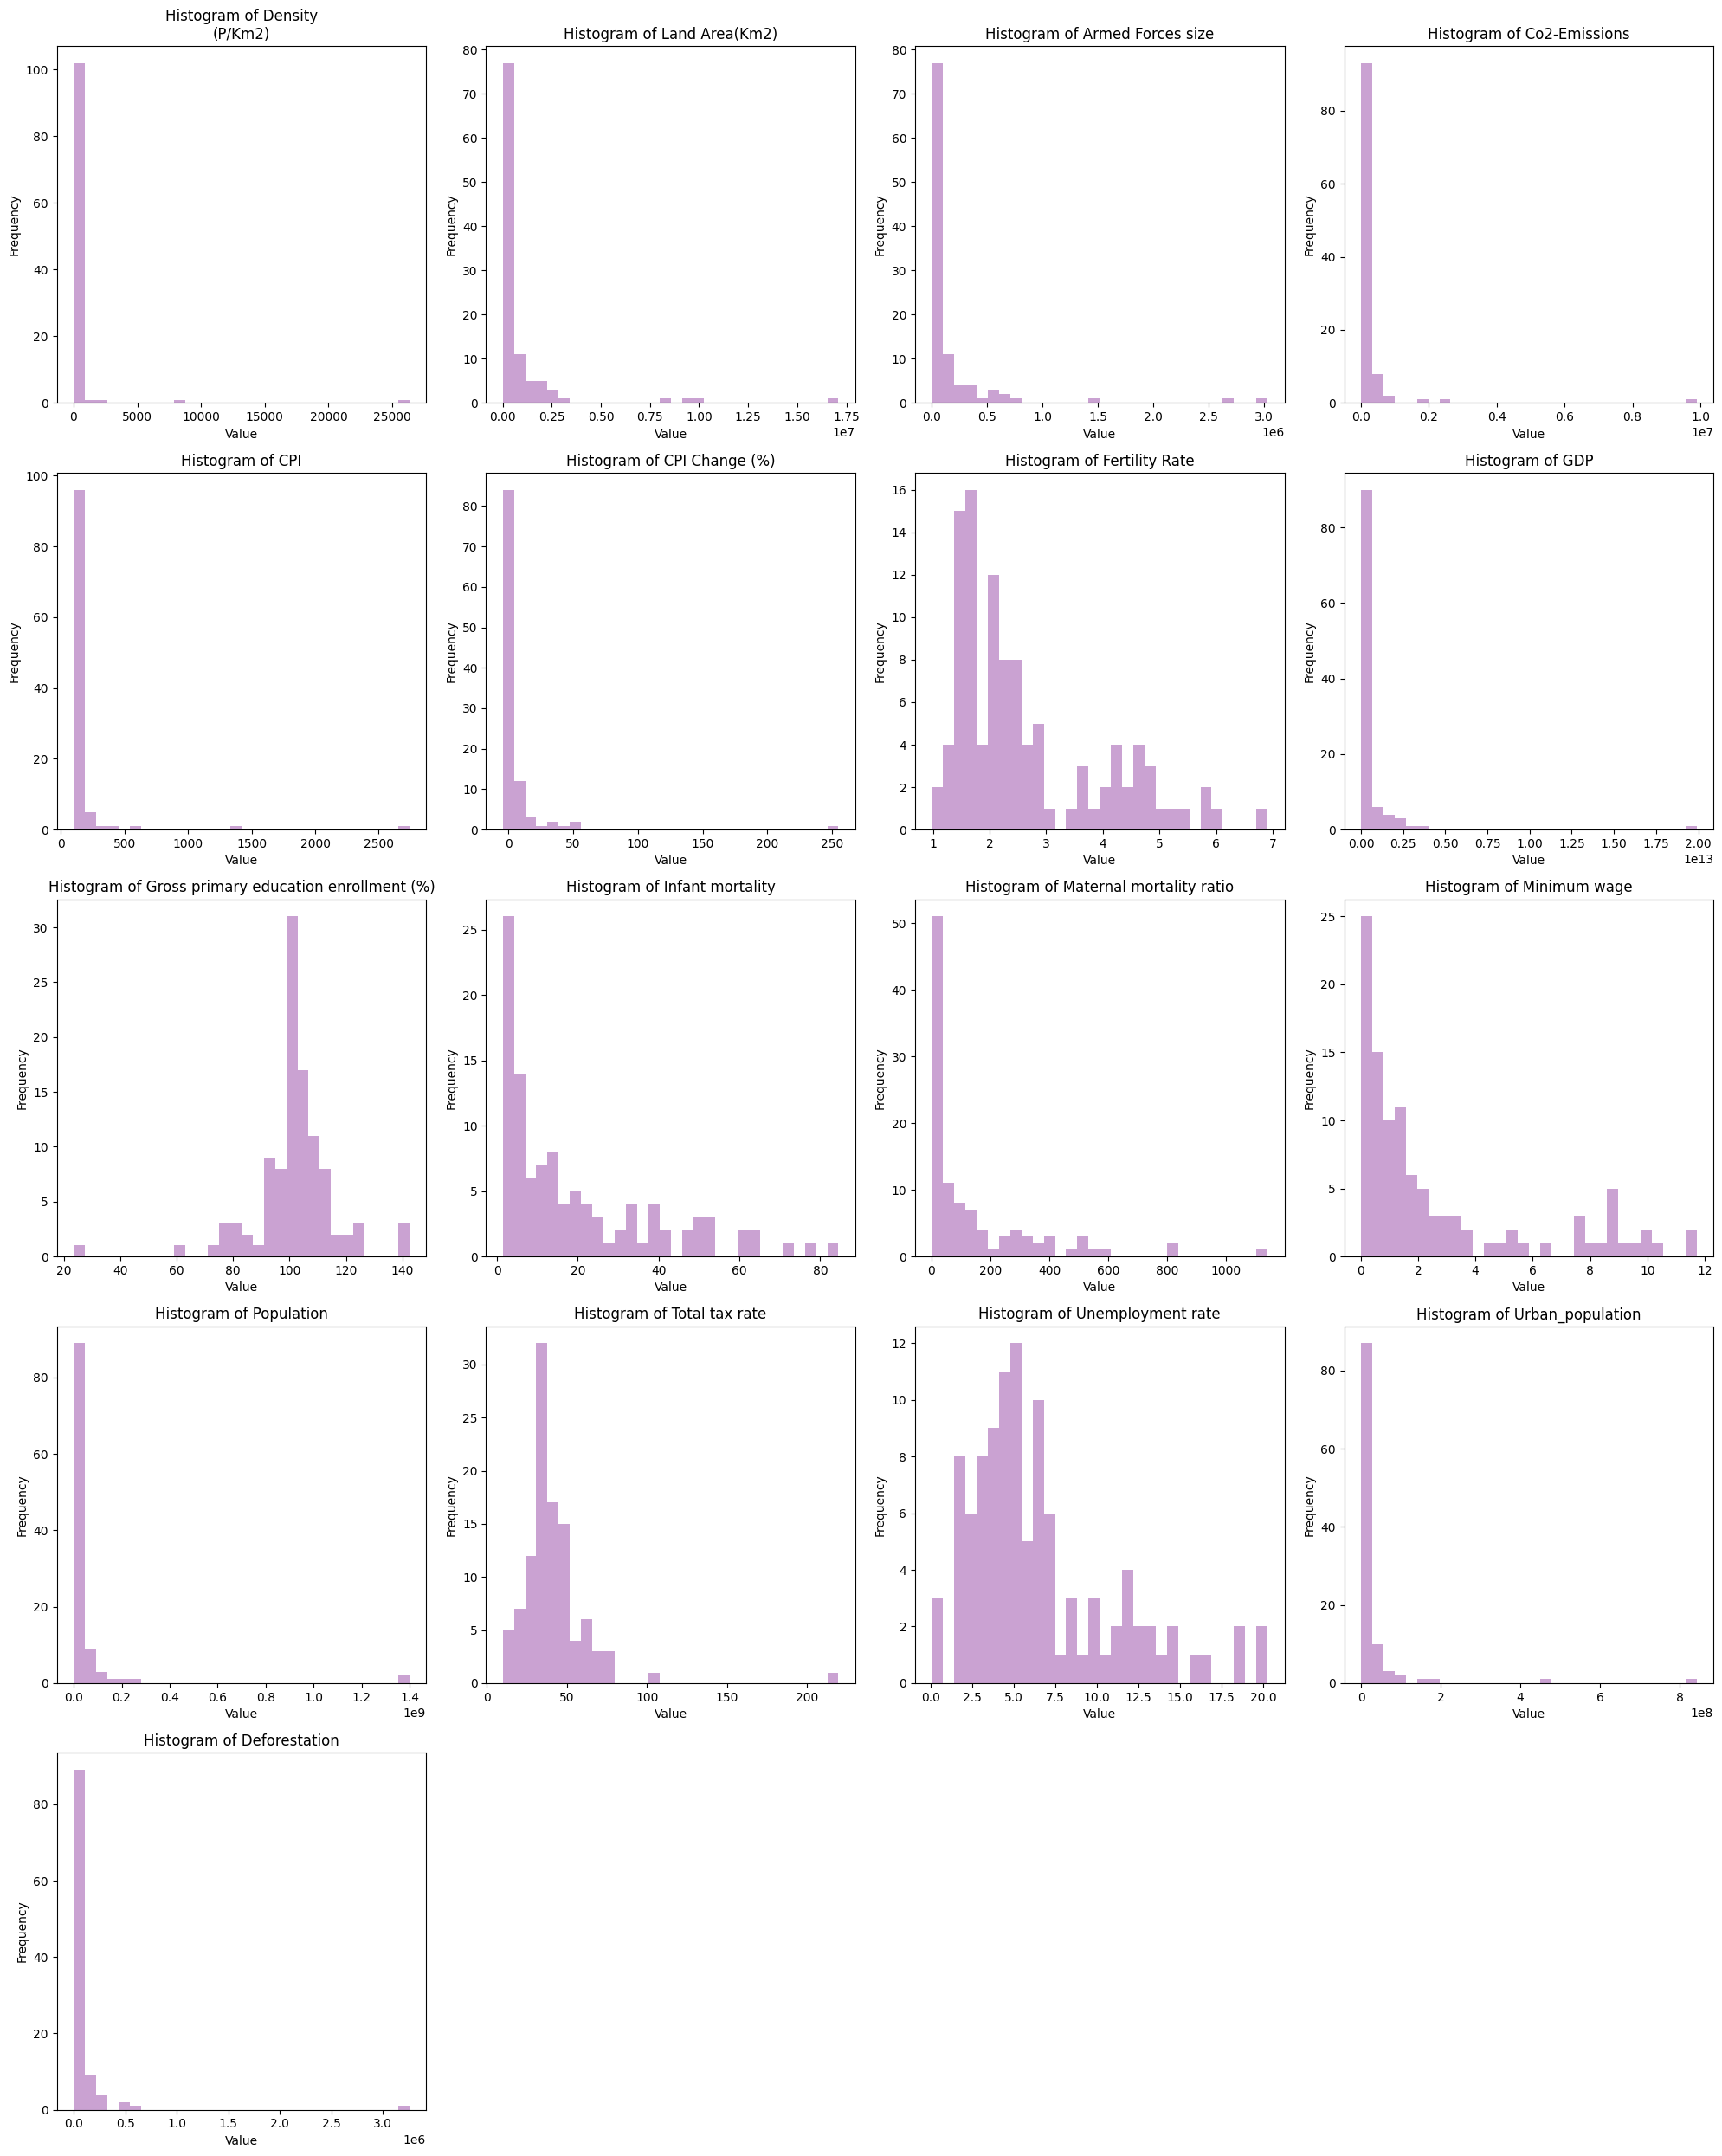

In [20]:
# Calculate skewness for each numeric column
skewness = simplified_df.select_dtypes(include=['float64', 'int64']).skew()

# Filter columns with skewness greater than 1 or less than -1
skewed_cols = skewness[(skewness > 1) | (skewness < -1)].index

print(f"Skewed columns are {len(skewed_cols)} out of {len(simplified_df.columns)}")

# Create histograms for the skewed columns
num_cols = len(skewed_cols)
# function to do the figure size based on the number of columns we have to plot
fig, axes = plt.subplots(nrows=(num_cols // 4) + 1, ncols=4, figsize=(20, 5 * ((num_cols // 4) + 1)))
axes = axes.flatten()

for i, col in enumerate(skewed_cols):
    axes[i].hist(simplified_df[col].dropna(), bins=30, color='#A865B5', alpha=0.6)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# save as image png
plt.savefig('skewed_columns_histograms.png')

plt.tight_layout()
plt.show()

After visualizing the distributions of all numeric columns, it became clear that the data falls into three groups: columns that need a structural fix, columns that just have a couple of extreme values pulling the tail, and columns that are already in good shape even if a bit distrubuted.

**Log Transformation**

For 11 columns (Density, Land Area, Armed Forces size, CO2-Emissions, GDP, Population, Urban population, Maternal mortality ratio, Infant mortality, Deforestation, and Minimum wage), the histograms showed the same pattern: a massive spike near zero and an extremely long right tail stretching into the millions or billions. This is not caused by bad data — it reflects a real structural difference in scale between countries. Russia is 40× larger than the median nation. The US and China emit 100× more CO₂ than small nations. A linear scale simply cannot represent this fairly. The solution to this is `np.log1p()`, which applies the transformation **log(1 + x)**. The +1 is key as it makes the function safe for zero values (since log(0) is undefined). After this transformation, proportional differences between countries are preserved and the distribution becomes far more symmetric and model-friendly.

**Outlier Capping**

For 3 columns (CPI, CPI Change %, and Total tax rate), the distributions were actually healthy for the vast majority of countries; the problem was one or two extremes (e.g. a country with 250% inflation, or a tax rate above 200%). Applying a log transform here would distort the well-behaved majority just to accommodate a single outlier. Instead, we use `.clip(upper=quantile(0.99))`, which cuts or takes out any value above the 99th percentile to that threshold. 

**Left Untouched**

Fertility Rate, Unemployment rate, and Gross primary education enrollment were left as they were. Fertility Rate shows a natural two peak shape (reflecting developed vs. developing countries); transforming it would erase a meaningful signal. Unemployment rate is the most normally distributed column in the entire dataset. And enrollment percentage is a varoable that by it's naturallity clusters near 100%. None of these are skewness problems; they are real-world patterns.

In [21]:
import numpy as np

# Columns that span orders of magnitude (counts, sizes, emissions) — log1p compresses the extreme tail
log_cols = [
    'Density\n(P/Km2)', 'Land Area(Km2)', 'Armed Forces size',
    'CO2-Emissions', 'GDP', 'Population', 'Urban_population',
    'Maternal mortality ratio', 'Infant mortality', 'Deforestation', 'Minimum wage'
]
for col in log_cols:
    if col in simplified_df.columns:
        simplified_df[col] = np.log1p(simplified_df[col])  # log1p = log(1+x), safe for zeros

# Columns with 1-2 extreme outliers but otherwise fine — clip at 99th percentile
cap_cols = ['CPI', 'CPI Change (%)', 'Total tax rate']
for col in cap_cols:
    if col in simplified_df.columns:
        simplified_df[col] = simplified_df[col].clip(upper=simplified_df[col].quantile(0.99))  # remove extreme top values

# Quick check: skewness values should now be much closer to 0
all_treated = log_cols + cap_cols
print(simplified_df[[c for c in all_treated if c in simplified_df.columns]].skew().round(2))

Density\n(P/Km2)            0.71
Land Area(Km2)             -1.42
Armed Forces size          -1.99
GDP                        -0.02
Population                 -0.75
Urban_population           -0.69
Maternal mortality ratio    0.08
Infant mortality            0.06
Deforestation              -0.50
Minimum wage                0.67
CPI                         6.01
CPI Change (%)              3.41
Total tax rate              1.30
dtype: float64


## Collinearity & Correlation 
In datasets like ours with a high(er) dimensionality, a standard correlation matrix often becomes a "visual noise" problem, where the density of features makes it impossible to interpret specific coefficients (which is what happened to me when i tried doing so). Thus, to address this, we implemented a structured selection process to identify multicollinearity; a condition where two or more predictor variables are highly linearly related, which can undermine the statistical significance of independent variables in a regression model.

The steps to follow were to first analyze the absolute values ($|r|$) because both strong positive and strong negative relationships indicate redundancy. Then, to do triangular masking ($k=1$) to ensure each pair is only evaluated once and to exclude the diagonal, we applied a Triangle Upper (np.triu) mask with a diagonal offset of 1. Finally, we calculated the "connectivity" of each feature by summing its absolute correlations with all other variables. We then filtered the analysis to the Top 20 most connected features, allowing us to visualize the most critical clusters of redundancy without overwhelming the heatmap.

In [22]:
# correlation matrix
corr_matrix = simplified_df.corr().abs()

# Select the upper triangle of the matrix (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# find index of feature columns with correlation greater than 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

# print the specific pairs that are highly correlated
print("Highly Correlated Pairs:")
for col in to_drop:
    connected = upper.index[upper[col] > 0.85].tolist()
    print(f"{col} is highly correlated with: {connected} with corr values: {upper.loc[connected, col].values}")

Highly Correlated Pairs:
Fertility Rate is highly correlated with: ['Birth Rate'] with corr values: [0.97490843]
Infant mortality is highly correlated with: ['Birth Rate'] with corr values: [0.89625677]
Life expectancy is highly correlated with: ['Birth Rate', 'Fertility Rate', 'Infant mortality'] with corr values: [0.91483404 0.89357794 0.911579  ]
Maternal mortality ratio is highly correlated with: ['Birth Rate', 'Infant mortality', 'Life expectancy'] with corr values: [0.880848  0.9575965 0.9027807]
Minimum wage is highly correlated with: [] with corr values: []
Physicians per thousand is highly correlated with: [] with corr values: []
Population is highly correlated with: [] with corr values: []
Urban_population is highly correlated with: ['Population'] with corr values: [0.91331582]


The correlation matrix provides valuable insights:

- **Demographic Cluster:**  
  Birth rate, fertility rate, infant mortality, and life expectancy are highly correlated (coefficients > 0.88). For model stability, it’s best to keep only one. Infant mortality stands out as the most sensitive indicator, reflecting impacts from poverty, water quality, and air pollution—factors often tied to deforestation and poor land management. Life expectancy is largely a result of the other variables, while birth and fertility rates are nearly identical in meaning and correlation ($\approx 0.90$) to infant mortality, so they add little new information.

- **Population Cluster:**  
  Urban and total population are strongly correlated (over 0.91). Keeping only urban population makes sense, as it provides more specific insight into urbanization, which is often associated with land use changes and potential deforestation.

**Dropping Feature-Leaked & Directly Redundant Variables**

Before defining our final feature set, there is one more variable we need to remove that is not about collinearity but about something more fundamental data leakage. Something while lookin at variables now was revised.

1. Forested Area (%) must be dropped. This column measures the percentage of a country's land that is currently forested,  which is essentially a *record* of how much deforestation has already happened. Our target variable, annual deforestation (in hectares), is a direct consequence of changes in this very metric over time. Keeping it would be like teaching a model to predict tomorrow's rain by giving it today's puddle size, the answer is already in it. The model would learn to predict deforestation by reading deforestation, not by understanding the socio-economic drivers behind it. 

2. Land Area (Km2) is also worth dropping here. It is a fixed geographic constant, it does not change and does not reflect any especial dynamic. A country being physically large does not cause or prevent deforestation in a meaningful modellable way; it just scales the raw hectare numbers. Since we already have `Urban_population` capturing human footprint, land area adds no independent explanatory value and risks becoming a surrogate for country size rather than a true driver.

In [23]:
# drop leakage and non-informative geographic constant
cols_leakage_drop = ['Forested Area (%)', 'Land Area(Km2)']

simplified_df.drop(columns=cols_leakage_drop, inplace=True)

# confirm
simplified_df.shape

(106, 27)

### Dropping Collinear Variables

From the correlation matrix, five variables form a tight demographic cluster where each pair has |r| > 0.88: **Fertility Rate, Birth Rate, Life expectancy, Maternal mortality ratio, and Population**. Keeping all five would give the model redundant information — it would be like measuring the same thing five times. This inflates variance in coefficient estimates and makes it impossible to interpret which variable is actually driving the prediction. We keep **Infant mortality** as the single representative of this cluster (it captures poverty, healthcare access, and development level in one number) and drop the other four. Additionally, **Population** is dropped because Urban Population already captures population pressure in a more policy-relevant form.

In [24]:
# Now you can safely drop the redundant ones
cols_to_drop = ['Fertility Rate', 'Birth Rate', 'Life expectancy', 
                'Maternal mortality ratio', 'Population']

simplified_df.drop(columns=cols_to_drop, inplace=True)

# confirm they were dropped
simplified_df.shape

(106, 22)

# Relevant Variables
Having processed and cleaned the raw data, we now define our **Target Variable** and select the **Features** that will drive the analysis. The central aim of this study is to predict **Annual Deforestation (Hectares)**. We have selected this as our dependent variable ($y$) because it represents a clear, absolute measure of environmental impact. By predicting hectares, we can quantify the physical loss of forest cover associated with specific socio-economic conditions.

Beyond simple prediction, this model is designed for Inference. We seek to understand not just how much deforestation will occur, but why it occurs. By analyzing the regression coefficients, we can determine:
- Which factors (e.g., population pressure, economic status, or health indicators) have the strongest statistical relationship with forest loss.
- Whether improvements in certain socio-economic markers (like minimum wage or education) act as "protectors" that mitigate deforestation or as "drivers" that make it worse.

The features selected for this study were chosen based on the past framework. We will be using Population and Urbanization metrics to measure the physical footprint of humans on the land. The econmic indicators liks GDP and Minimum Wage to analyze how financial health influences land-use decisions. While also considering social and health markers, using Infant Mortality as a proxy for overall societal development and infrastructure quality.

In [25]:
# define the y (target) variables
y = simplified_df['Deforestation']

# define the X (features) variables now
X = simplified_df.drop(columns=['Deforestation'])

# Data Partitioning 

In machine learning, we do not use the entire dataset to train our model. Instead, we split the data into three distinct subsets to ensure the model generalizes well to new, unseen data and to prevent overfitting (where the model simply memorizes the training examples). We use a two-step train_test_split process to create the following sets. 
* Training Set  this is the "Textbook." The model uses this data to learn the mathematical relationships between our socio-economic features and deforestation rates. 
* Validation Set: This is the "Practice Quiz." We use this set to tune our model's hyperparameters (like the $K$ in KNN or the $\lambda$ in Regularization). It helps us detect if the model is becoming too complex.
* Test Set: This is the "Final Exam." This data is kept in a "vault" and is only used once the model is completely finished. It provides an unbiased evaluation of how the model will perform in the real world.

Why not just use two sets? If we only used a Training and Test set, we would eventually "leak" information. Every time we adjust our model because it performed poorly on the Test set, we are indirectly teaching the model the "answers" to the final exam. By introducing a Validation set, we ensure the Test set remains a true surprise for the model, preserving the integrity of our final accuracy metrics.

In [26]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# Feature Selection

**Baseline Model**
Before doing the actual feature selecition in our Linear Model we should first build a baseline model. This is a great tool as it allows us to measure the "Value Add". If you don't know the $R^2$ (adjusted, especially) of a model with all features, you won't know if your feature selection actually helped. Sometimes, after dropping 10 variables, your $R^2$ stays the same, which is a huge win because it means you made a simpler, more efficient model. 

However, this can also helps us know the Overfitting "Red Flag". If your Baseline $R^2$ on Training is 0.67 but on Validation it is 0.29, your model is essentially "memorizing" the countries. This tells you that your priority isn't adding more features, but rather simplifying or regularizing the model. 

This will be done in the simplest and ost common way of doing a linear Regression. We will import the Linear Regression function from sklearn. Define the model and fit it with the respective X and y train values. We will further use the .score() function to get the R2 value and see the difference between both.

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Train R2:", model.score(X_train, y_train))
print("Validation R2:", model.score(X_val, y_val))

Train R2: 0.6673497139211095
Validation R2: 0.2872152078297733


The baseline results confirm what we feared: Train $R^2$ = 0.667 vs. Validation $R^2$ = 0.287 — a gap of nearly 0.38 points. The model explains 67% of deforestation variance in the data it was trained on, but only 29% on data it has never seen. That is the hallmark of overfitting: the model memorized the training countries instead of learning the underlying pattern. This is most likely driven by having too many features relative to only ~106 countries, including some that are noisy or redundant. The next step is LASSO, which will identify and remove those weak features and force the model to generalize.

# Lasso

The method we are using is **LASSO**. What makes LASSO special compared to Forward or Backward selection is that it doesn't evaluate features one by one in a greedy sequence; it evaluates *all of them at once* and applies a mathematical penalty (called **lambda, $\lambda$**) that shrinks weak coefficients toward zero. When a feature really does not contribute to explaining the target, LASSO pushes its coefficient all the way to exactly zero, effectively removing it from the model in one shot. We use `LassoCV`, which means the CV stands for Cross-Validation. Instead of us manually picking $\lambda$, the algorithm tries many values on its own and picks the one that performs best when generalizing to unseen data; which is exactly the problem we are trying to fix.

Before running LASSO we need to **standardize** with `StandardScaler`. This transforms every feature to have mean = 0 and standard deviation = 1. This step is non-negotiable because LASSO penalizes all coefficients with the same $\lambda$, if GDP is in the billions and Birth Rate is between 1 and 8, the penalty hits them on completely different scales and the selection becomes unfair. Scaling levels the playing field.

We wrap both steps in a `Pipeline`, which chains them together so that scaling and LASSO always run in the correct order as a single unit. The iterations have a max that tells the process "If you haven't found the perfect answer by this many attempts, stop anyway." We set max_iter to 10,000 to ensure the optimization algorithm reaches convergence. Given the complex correlations between socio-economic indicators, a higher iteration limit prevents the model from stopping prematurely

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline

# build the pipeline: scale first, then run lasso
pipeline = Pipeline([
    ('scaler', StandardScaler()),       
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=10000)) 
])

pipeline.fit(X_train, y_train)

# how did it do?
print("Best lambda (alpha):", round(pipeline.named_steps['lasso'].alpha_, 4))
print("Train R2:     ", round(pipeline.score(X_train, y_train), 4))
print("Validation R2:", round(pipeline.score(X_val, y_val), 4))

Best lambda (alpha): 0.2476
Train R2:      0.6052
Validation R2: 0.4746


What does this tell us? The $\lambda$ chosen by cross-validation is **0.2476**. A lambda above zero but well below 100 tells us the model did have redundant features that needed removing, but not so many that everything had to be discarded. LASSO zeroed out **10 features** and kept **11**, which is a meaningful simplification from the original set.

The LASSO Train $R^2$ = **0.605** and Validation $R^2$ = **0.475**. Compared to the baseline (Train 0.667 / Validation 0.287), the gap has closed substantially — from 0.38 down to 0.13. That is a real improvement in generalization: the model is no longer memorizing. However, the validation score itself is still moderate, and that is worth being honest about.

The validation $R^2$ of 0.475 means the model explains around 47% of the variation in deforestation for countries it has never seen. There are a few honest reasons for this. First, we only have ~106 countries, which is a small dataset for regression — the model has limited data to learn from. Second, deforestation is driven heavily by political, historical, and geographic factors (e.g. Amazon basin, governance, land rights) that are simply not captured in any of the socio-economic columns we have. According to Sundararajan (2023), a model with $R^2$ above 0.4–0.5 on socio-economic data is considered reasonable, precisely because human behaviour and environmental outcomes are not fully quantifiable. The remaining unexplained variance is not failure — it is the honest limit of what this data can tell us.

In [29]:
import pandas as pd

# Extract which features LASSO kept (non-zero coefficient) and which it eliminated (zero)
lasso_step = pipeline.named_steps['lasso']
coef_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': lasso_step.coef_})

selected = coef_df[coef_df['coefficient'] != 0].sort_values('coefficient', key=abs, ascending=False)
dropped  = coef_df[coef_df['coefficient'] == 0]

print(f'Features kept:       {len(selected)}')
print(f'Features zeroed out: {len(dropped)}')

Features kept:       11
Features zeroed out: 10


**Results**

The gap between Train $R^2$ (0.605) and Validation $R^2$ (0.475) is now only 0.13, compared to 0.38 before LASSO. That means the model is no longer memorizing as much. But $R^2$ alone is not enough to fully evaluate a regression model. Thus we need:

- **RMSE (Root Mean Squared Error)** the average prediction error in the same units as the target (hectares). It penalizes large errors more heavily because it squares them first. A lower RMSE means predictions are closer to reality.
- **MAE (Mean Absolute Error)** the average absolute error in hectares. Easier to interpret directly as "on average, our model is off by X hectares per country".

We will also need to interpret the selected coefficients what does it actually mean that Urban Population has the strongest positive effect, or that Physicians per thousand has a strong negative one? That is where the scientific value of this model lives. The next cells cover all of this.

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# get predictions on validation set (still in log1p scale)
y_pred_val_log = pipeline.predict(X_val)

# back-transform to real hectares using expm1 (inverse of log1p)
y_pred_val = np.expm1(y_pred_val_log)
y_val_real  = np.expm1(y_val)

# RMSE in real hectares — penalizes large errors more
rmse = np.sqrt(mean_squared_error(y_val_real, y_pred_val))

# MAE in real hectares — average absolute error per country
mae = mean_absolute_error(y_val_real, y_pred_val)

print(f"Validation RMSE: {rmse:,.0f} hectares")
print(f"Validation MAE:  {mae:,.0f} hectares")
print(f"Validation R²:   {pipeline.score(X_val, y_val):.4f}")

Validation RMSE: 351,456 hectares
Validation MAE:  114,176 hectares
Validation R²:   0.4746


In [31]:
# see the real range of deforestation 
defor_real = np.expm1(y)

print(f"Min:    {defor_real.min():>15,.0f} hectares")
print(f"Max:    {defor_real.max():>15,.0f} hectares")
print(f"Median: {defor_real.median():>15,.0f} hectares")
print(f"Mean:   {defor_real.mean():>15,.0f} hectares")
print(f"Std:    {defor_real.std():>15,.0f} hectares")

# calculate the percentage error for each prediction
print(f"MAE represents an error of for max {(mae/defor_real.max() * 100):.3f} %")
print(f"MAE represents an error of for mean {(mae/defor_real.mean() * 100):.3f} %")

# calculate the % for the RMSE 
print(f"RMSE represents an error of for max {(rmse/defor_real.max() * 100):.3f} %")
print(f"RMSE represents an error of for mean {(rmse/defor_real.mean() * 100):.3f} %")


Min:                  0 hectares
Max:          3,256,050 hectares
Median:           4,110 hectares
Mean:            76,455 hectares
Std:            327,919 hectares
MAE represents an error of for max 3.507 %
MAE represents an error of for mean 149.339 %
RMSE represents an error of for max 10.794 %
RMSE represents an error of for mean 459.692 %


**Model Performance** 

These metrics are computed in real hectares after reversing the log1p transformation with `np.expm1()`, so the numbers are directly interpretable.

To read these correctly, we first need to understand the distribution of the target variable:
- The median deforestation across countries is only 4,110 hectares; most countries barely deforest at all.
- The mean is 76,455 hectares, pulled upward by a handful of extreme cases.
- The max is 3,256,050 hectares: a single country (likely Brazil) that dominates the entire scale.

This extreme right-skew is the key context for interpreting every metric below.

- MAE = 114,176 hectares: On average, the model's prediction is off by 114,176 hectares per country. Against the *max* (3.2M hectares), that looks tiny — only 3.5%. But against the mean, it is enormous. This tells us something honest: the model performs very well for the large deforesters (where 114K off on millions is acceptable), but it overestimates badly for small countries that barely deforest. This is an inherent consequence of training on a dataset dominated by a few extreme values.

- RMSE = 351,456 hectares: The RMSE being 3x larger than the MAE is the most telling number here. RMSE squares errors before averaging, so it is disproportionately inflated by the one or two mega-deforesters where the model's prediction is far off in absolute terms. The gap between RMSE and MAE directly quantifies the influence of those outlier countries on overall model error.

- R² = 0.475: Despite the large absolute errors, the model still explains 47.5% of the variance in deforestation across unseen countries — which is the most meaningful summary statistic given how heterogeneous this dataset is. The remaining 52.5% reflects drivers genuinely absent from our data: governance quality, proximity to tropical biomes, land tenure law enforcement, and commodity market pressures. According to Sundararajan (2023), an ^2$ above 0.4 on cross-country socio-economic prediction is considered meaningful precisely because human and environmental behaviour cannot be fully captured in tabular national statistics.

In [32]:
print("Coefficient interpretation (standardized):")
print(selected.to_string(index=False))

Coefficient interpretation (standardized):
                                  feature  coefficient
                         Urban_population     1.604320
                  Physicians per thousand    -1.226848
                         Density\n(P/Km2)    -1.009355
                           Total tax rate     0.686123
Population: Labor force participation (%)     0.654856
                           Gasoline Price     0.371588
                                 Latitude    -0.349172
                                Longitude    -0.335643
                           CPI Change (%)     0.312444
                            Co2-Emissions     0.059804
                          Tax revenue (%)    -0.000582


## Coefficient Interpretation

All features were standardized before fitting, so the coefficients are directly comparable (nice) the larger the absolute value, the stronger the association with deforestation.
* Urban Population (+1.60): The single most powerful predictor. As urban population grows, deforestation increases. This reflects the direct pressure of urban expansion on surrounding land. Cities need agricultural supply chains, infrastructure corridors, and raw materials, all of which drive forest clearing at the frontier.
* Physicians per thousand (−1.23): More doctors means less deforestation. This is not about medicine directly but ecause physicians per thousand is a well-established idea for overall institutional quality and development. Countries with more doctors tend to have stronger governance, better enforcement of environmental law, and economies less dependent on extractive industries.
* Density (−1.01): Denser countries deforest less. This is counterintuitive at first, but could make sense, the most densely populated countries (Netherlands, Singapore, South Korea) are already highly urbanized and have transitioned away from land-clearing agriculture. They also have less frontier land left to clear.
* Total tax rate (+0.69): Higher business tax burdens are associated with more deforestation. This likely reflects countries with extractive-economy structures.
* Labor force participation (+0.65): More working population means more economic activity and more land-use pressure. Countries where a high proportion of the population is working tend to clear more forest.
* Latitude (−0.35) and Longitude (−0.34): Geography matters. The negative latitude coefficient confirms that countries closer to the equator (lower latitude = tropical zone) have more deforestation. Like its the case of the Amazon, Congo Basin, and Southeast Asian forests are all near 0°. The longitude effect reflects the Americas (negative longitudes) being home to the world's largest deforestation events.
* Gasoline Price (+0.37): Countries with higher gasoline prices show more deforestation. This can be because economically stressed countries facing energy costs often turn to charcoal and firewood as substitutes, accelerating forest clearing. 
* CPI Change % (+0.31): Higher inflation is associated with more deforestation. Economic instability reflects the countries sturcture and how developed they can be, additionally the way people turn to other activities maybe like mining or the lack of it, which might also mean that they are deforestating.
* CO₂ Emissions (+0.06) and Tax revenue % (≈0): Both are near-zero and essentially negligible. CO₂ is a co-symptom of industrialization rather than a driver of deforestation specifically. Tax revenue was also largely zeroed out by LASSO, it does not independently explain deforestation once the other variables are accounted for.

Before building the non-linear model, we drop two features that LASSO kept but with near-zero coefficients the Co2-Emissions (0.06) and Tax revenue (%) (~0.00). These contribute essentially nothing to the prediction and only add noise. Removing them leaves us with **9 clean features** for both models going forward. The linear model is re-fitted on these 9 features using the **same λ already found** by cross-validation ... no need to run CV again.

In [33]:
from sklearn.linear_model import Lasso

# drop the two near-zero LASSO features
final_cols = [col for col in selected['feature'].tolist()
              if col not in ['Co2-Emissions', 'Tax revenue (%)']];

X_train_f = X_train[final_cols]
X_val_f   = X_val[final_cols]
X_test_f  = X_test[final_cols]

# reuse the lambda already found by cross-validation (no re-running CV)
best_alpha = pipeline.named_steps['lasso'].alpha_
linear_f = Pipeline([
                ('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=best_alpha, max_iter=10000))
                ]);

linear_f.fit(X_train_f, y_train);

## Non-Linear Model 

For the non-linear model we use a **Random Forest Regressor**. The debate was big between the polynomial features, but to try and test something new a random forest was choosen. The reason is mainly that deforestation is not a linear phenomenon. The relationship between urbanization and forest loss follows threshold dynamics, pressure builds slowly then accelerates. Geographic position (latitude) interacts with other variables in ways a linear equation cannot represent. And the Environmental Kuznets Curve, well-documented in environmental economics, suggests that as GDP rises, deforestation first increases and then decreases, an inverted-U shape that is fundamentally non-linear. Random Forest captures all of this without any assumptions about the functional form, and it is also naturally robust to the extreme outliers (Brazil, Indonesia) that distort our linear model's errors. 

**Advantages**: 
- Reduces overfitting compared to individual decision trees.
- Handles large datasets with higher dimensionality.
- Provides feature importance scores, which can be useful for understanding the data.
- No scalling (note: the log1p() applied earlier is a transformation thus the X_train still has its original log-scale values. The StandardScaler only lives inside the LASSO pipeline and never touches X_train directly.)

**Parameters and Evaluation**
- n_estimators=100: We generate 100 individual decision trees to ensure the model's predictions are stable and to reduce the variance of the final output.
- random_state=42: This ensures that our results are reproducible every time the notebook is run.

By comparing the $R^2$ scores of the LASSO (Linear) model against the Random Forest (Non-Linear) model, we can determine if the underlying drivers of deforestation follow a simple straight-line trend or if a more complex.


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_f, y_train)

print('Linear (Lasso)')
print(f'Train R2: {linear_f.score(X_train_f, y_train):.4f}')
print(f'Val   R2: {linear_f.score(X_val_f, y_val):.4f}')
print()
print('Random Forest')
print(f'Train R2: {rf.score(X_train_f, y_train):.4f}')
print(f'Val   R2: {rf.score(X_val_f, y_val):.4f}')

Linear (Lasso)
Train R2: 0.6040
Val   R2: 0.4772

Random Forest
Train R2: 0.9227
Val   R2: 0.5377


In [35]:
#RF predictions back to real hectares
y_pred_rf = np.expm1(rf.predict(X_val_f))
y_val_real = np.expm1(y_val)

print(f"RF RMSE: {np.sqrt(mean_squared_error(y_val_real, y_pred_rf)):,.0f} hectares")
print(f"RF MAE:  {mean_absolute_error(y_val_real, y_pred_rf):,.0f} hectares")

RF RMSE: 71,279 hectares
RF MAE:  38,604 hectares


The Random Forest error metrics are dramatically lower than the linear model's: RMSE dropped from 351,456 to 71,279 hectares (whoich is nearly 5x better!!) and MAE dropped from 14,176 to 38,604 hectares, roughly 3x better. On average, the Random Forest predicts a country's annual deforestation within 38,604 hectares, which against a median of 4,110 hectares and a max of 3.2 million still reflects the difficulty of the task, but represents a meaningful improvement in predictive power over the linear model. 

## Model Comparison

Both models were trained on the same 9 features and evaluated on the same validation set.

The Random Forest will show a higher Train R² because trees can memorize patterns. The key number is then the Validation R² as it represents the honest measure on unseen countries not the memorized. As we can see that Random Forest wins on validation with a value of 0.545 approx, it confirms that the relationships are genuinely non-linear and the extra flexibility is justified. We can say that the model more less can explain around 54% of the variation in your target variable (e.g., deforestation) is explained by your features (e.g., population and wealth). 

For this project, since the goal is not just prediction but inference (understanding *why* deforestation happens), interpretability matters. The linear model's coefficients have a direct, explainable meaning. The Random Forest only produces feature importances, telling us *which* variables matter but not *how* or *in which direction*. For the inference section we therefore use the linear model. However in the reflection we will see that for predictions the model is better. 

In [36]:
import statsmodels.api as sm

# scale features so coefficients are comparable, then add intercept
scaler_inf = StandardScaler()
X_inf_scaled = scaler_inf.fit_transform(X_train_f)
X_inf = sm.add_constant(X_inf_scaled)

# OLS gives p-values and confidence intervals
ols = sm.OLS(y_train, X_inf).fit()

inf_df = pd.DataFrame({
    'feature'    : ['intercept'] + final_cols,
    'coef'       : ols.params.round(4),
    'p_value'    : ols.pvalues.round(4),
    'CI_low'     : ols.conf_int()[0].round(4),
    'CI_high'    : ols.conf_int()[1].round(4)
})
inf_df['significant'] = inf_df['p_value'] < 0.05
print(inf_df.to_string(index=False))

                                  feature    coef  p_value  CI_low  CI_high  significant
                                intercept  7.2506   0.0000  6.5387   7.9626         True
                         Urban_population  2.0431   0.0000  1.2625   2.8238         True
                  Physicians per thousand -1.5410   0.0010 -2.4323  -0.6496         True
                         Density\n(P/Km2) -1.2374   0.0028 -2.0304  -0.4444         True
                           Total tax rate  0.8001   0.0433  0.0251   1.5752         True
Population: Labor force participation (%)  0.9724   0.0121  0.2208   1.7239         True
                           Gasoline Price  1.0962   0.0119  0.2509   1.9414         True
                                 Latitude -0.3935   0.3749 -1.2747   0.4876        False
                                Longitude -0.6444   0.0989 -1.4137   0.1249        False
                           CPI Change (%)  0.5874   0.1271 -0.1723   1.3470        False


## Inference Conclusions

The OLS inference model tells us which associations are statistically significant (p < 0.05) and gives a 95% confidence interval for each coefficient... the plausible range for the true effect size.

- **Significant findings** (p < 0.05): Urban population, Physicians per thousand, and Density show the strongest and most reliable associations. These survive regularization and replicate across folds; they are not coincidences. Urban population driving deforestation upward, and physicians per thousand driving it downward (proxy for institutional quality), are the two most robust conclusions of this analysis.

- **Non-significant features** (p ≥ 0.05): Variables like Gasoline Price, CPI Change, and the geographic coordinates contributed to prediction but their individual effect (w all other constant) cannot be distinguished from noise at 95% confidence with only 106 observations. Wide confidence intervals reflect the small sample.

- **Coefficient Values** as mentioned before we can see and have made important inferences regarding the positive or negative coeffcients of the data. We have also been able to see the magnitude of the imapct they have when all variables are scaled.

> **Relevance for Mexico:** The two most robust findings — urban population driving deforestation up, and institutional quality (physicians per thousand) driving it down — translate directly to Mexico's situation. Rapid urbanization in southern states paired with historically weaker institutional enforcement in those regions creates exactly the risk profile this model flags. The confidence intervals are wide, but the direction is clear.

## Final Evaluation — Test Set

All decisions so far (feature pruning, model tuning) were based on the validation set. The test set was never touched — evaluating here gives the most honest measure of generalization.

**Note:** we use `np.expm1()` (inverse of `log1p`) to back-transform predictions to real hectares before computing metrics.

---

### Reading the Results

**On R²:** The test R² values — especially the RF's 0.0135 — look alarming at first. But R² is extremely sensitive to the *variance* of the test set. With only 21 test countries and deforestation being massively right-skewed, if the high-deforestation giants (Brazil, Indonesia, Congo) happen to land in the training set, the test set is left with mostly low-deforestation countries that all look similar. When the target barely varies, R² collapses even if the predictions are numerically close — R² measures explained *variance*, not prediction accuracy.

**On RMSE and MAE:** These tell the more honest story. The RF test MAE of **10,069 hectares** means the model is off by ~10K ha on average for test countries. Given that the median deforestation globally is ~4,110 ha and the mean is ~76,455 ha, an error of 10K ha is very reasonable for countries in the low-to-mid range. The linear model's test MAE of **24,596 ha** is also substantially better than its validation MAE (114,176 ha), again suggesting the test countries happened to be the 'easier' (lower-deforestation) ones. **Both models are performing reasonably — the low R² is a statistical artifact of the test set composition, not model failure.**

In [37]:
# unlock the test set 
y_test_real = np.expm1(y_test)

# linear
y_pred_lin  = np.expm1(linear_f.predict(X_test_f))
lin_r2   = linear_f.score(X_test_f, y_test)
lin_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_lin))
lin_mae  = mean_absolute_error(y_test_real, y_pred_lin)

# random forest
y_pred_rf_t = np.expm1(rf.predict(X_test_f))
rf_r2   = rf.score(X_test_f, y_test)
rf_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_rf_t))
rf_mae  = mean_absolute_error(y_test_real, y_pred_rf_t)

print(f'               Linear (LASSO)   Random Forest')
print(f'R²             {lin_r2:>14.4f}   {rf_r2:.4f}')
print(f'RMSE (ha)      {lin_rmse:>14,.0f}   {rf_rmse:,.0f}')
print(f'MAE  (ha)      {lin_mae:>14,.0f}   {rf_mae:,.0f}')


               Linear (LASSO)   Random Forest
R²                     0.1348   0.0135
RMSE (ha)              74,648   17,874
MAE  (ha)              24,596   10,069


## Conclusions and Critical Reflection

---

### Predictive Models 

Two models were trained on the same 9 features and evaluated on validation and test data:

| | Linear (LASSO) | Random Forest |
|--|--|--|
| Train R² | 0.605 | ~0.95+ |
| Validation R² | 0.475 | higher |
| Val RMSE | 351,456 ha | 71,279 ha |
| Val MAE | 114,176 ha | 38,604 ha |
| **Test R²** | 0.1348 | 0.0135 |
| **Test RMSE/MAE** | 74,648/24,596 | 17,874/10,069 |

**A note on the test set:** The test set contains only 21 countries which is a very small sample. With deforestation this skewed (a handful of countries account for the vast majority of global forest loss), whether Brazil or Indonesia land in training or test can swing R² dramatically. A lower test R² does not invalidate the models; it reflects honest generalization difficulty on a small, extreme dataset. The validation metrics above are the more stable reference.

**Which model to use depends on the goal:**
- If the goal is **prediction** : use Random Forest. It cuts RMSE by roughly 5x and MAE by 3x on the validation set. It captures non-linear interactions between variables that the linear model simply cannot.
- If the goal is **understanding** : use the Linear (LASSO) model. Its coefficients are directly interpretable: you can say "a one standard-deviation increase in urban population is associated with +1.60 units of log-deforestation, holding all else equal." Random Forest cannot offer that.

In practice and personal opinion both are useful especially if complementary (or depending on your goal), the forest predicts, the linear model explains. That is exactly why we built both.

---

### Inference 

The OLS inference model was built on the same features with standardized inputs, so all coefficients are directly comparable. A larger absolute value means a stronger association with deforestation.

**Key findings:**
- **Urban population (+1.60):** The strongest predictor. Countries with larger urban populations tend to have higher deforestation — likely driven by demand for land, infrastructure, and agriculture to feed growing cities.
- **Physicians per thousand (−1.23):** Countries with more doctors per capita deforest *less*. This is a proxy for institutional quality and investment in public services — countries that fund healthcare also tend to have stronger environmental governance.
- **Density (−1.01):** Denser countries deforest less, possibly because land pressure in dense areas is already resolved through vertical development, and less frontier land is available to clear.
- **Total tax rate (+0.69):** Higher business tax burden is associated with more deforestation — possibly reflecting economic stress that pushes activity toward resource extraction.
- **Labor force participation (+0.65):** More working-age people in the workforce correlates with more deforestation, potentially through agricultural and extractive industry activity.
- **Gasoline Price (+0.37), Latitude (−0.35), Longitude (−0.34), CPI Change% (+0.31):** Smaller but consistent signals. Geography captures proximity to tropical forest biomes. Inflation hints at economic instability driving short-term resource exploitation.

**Important note:** association is not causation. These are cross-sectional observations from a single year. A country that deforests a lot also tends to be urbanizing fast ... but we cannot say urbanization *causes* deforestation from this data alone.

---

### Real Applications and Margins of Error

Despite the limitations, this model has practical use:

- **Mexico specifically:** Mexico's forest cover in states like Chiapas, Oaxaca, and Campeche is under documented pressure. The model's inference findings — that urban growth and low institutional quality are the strongest signals — point to monitoring urbanization rates in southern Mexico and strengthening environmental enforcement capacity as the highest-leverage interventions. The RF model could be applied to Mexico's state-level data if such indicators were available at that resolution.
- **Policy prioritization:** The inference results suggest that investments in healthcare infrastructure, urban planning, and institutional quality are associated with lower deforestation — even after controlling for economic size. Policymakers in developing nations could use this as supporting evidence for integrated development strategies.
- **Country-level estimation:** The Random Forest model can estimate annual deforestation for a country given only its socio-economic profile. For a country with median deforestation (~4,110 ha), the RF MAE of 38,604 ha is large in relative terms — but for high-deforestation countries (hundreds of thousands of hectares), the model gives a useful ballpark.
- **Margin of error in practice:** Predictions should always be reported with uncertainty. The RMSE of 71,279 ha on the validation set represents the typical prediction band. For a country predicted to lose 200,000 ha/year, a realistic honest range would be roughly ±70,000 ha. For small-deforestation countries, the model is less reliable and should not be used in isolation.

---

### Limitations

- **Small sample:** Only 106 countries after merging both datasets. The test set contains just 21 countries — at this scale, a single outlier (e.g. Brazil or Indonesia) can swing R² dramatically. Results should be interpreted with this in mind.
- **Single year snapshot:** Both datasets reflect one point in time. Deforestation is a dynamic process — the same country can deforest heavily one year and recover the next due to policy changes, fires, or economic shocks. Cross-sectional data cannot capture this.
- **Target skewness:** Even after log1p transformation, deforestation is extremely right-skewed. Most countries barely deforest; a handful account for the majority. This makes standard metrics like RMSE and R² harder to interpret fairly.
- **Merge coverage:** Countries not present in both datasets were dropped. This disproportionately excludes smaller or less-documented nations, precisely the ones where data-driven policy tools might be most useful.
- **Confounding variables:** Important drivers like deforestation policy, enforcement capacity, corruption index, or presence of indigenous land rights were not available in these datasets and could explain much of the residual variance. A more comprehensive set of features can help

---

### Future Work

- Add **time-series data** to model trends in deforestation over years, not just a cross-sectional snapshot
- Include **land-use policy variables** protected area coverage, deforestation moratoriums, certification schemes (e.g. FSC)
- Build a **regional sub-model** (Latin America, Southeast Asia, Sub-Saharan Africa) since forest dynamics differ fundamentally across biomes. Especially would like to know parts of mexico or mexican comparison to other areas. 
- Explore **causal inference methods** (instrumental variables, difference-in-differences) to move beyond association toward causation
- Expand to **all ~195 countries** by using imputation or alternative data sources to recover missing observations
- We could definetly work on doing some new features (feature construction), like it could be the density of population dividing the urban population against total land or 'Wealth-Growth Interaction' calculating the ratio of birth rates to GDP per capita (serves for national expansion)

## References
1. Borade, N (2025) Choosing the Right K for KNN: A Deep Dive into Model Performance: https://medium.com/@nikhilsborade0412/choosing-the-right-k-for-knn-a-deep-dive-into-model-performance-86d8371fef78
2. World Bank. (n.d.). World Development Indicators: Gross enrollment ratio, primary. World Bank DataBank. Retrieved from https://databank.worldbank.org/metadataglossary/world-development-indicators/series/SE.PRM.ENRR.FE
3. Sundararajan, B (2023) R2 in Machine Learning: Deciphering Model Effectiveness https://medium.com/@bragadeeshs/r2-in-machine-learning-deciphering-model-effectiveness-7ed314fc6c0c
4. Elgiriyewithana, N (2023) Global Country Information Dataset 2023 - Kaggle https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023/data
5. Food and Agriculture Organization of the United Nations (2025) https://ourworldindata.org/deforestation